<a href="https://colab.research.google.com/github/SahilRaut80/Brain_tumor_detection./blob/main/Brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.utils import shuffle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_dir = '/content/drive/MyDrive/Testing'
train_dir = '/content/drive/MyDrive/Training'
train_paths = []
train_labels = []

for label in os.listdir(train_dir) :
  for image in os.listdir(os.path.join(train_dir , label)) :
    train_paths.append(os.path.join(train_dir , label , image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths,train_labels)

test_paths = []
test_labels = []

for label in os.listdir(test_dir) :
  for image in os.listdir(os.path.join(test_dir , label)) :
    test_paths.append(os.path.join(test_dir , label , image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths,test_labels)


In [ ]:
print(train_paths)


['/content/drive/MyDrive/Training/pituitary/Tr-pi_0857.jpg', '/content/drive/MyDrive/Training/pituitary/Tr-pi_0532.jpg', '/content/drive/MyDrive/Training/notumor/Tr-no_1034.jpg', '/content/drive/MyDrive/Training/meningioma/Tr-me_0760.jpg', '/content/drive/MyDrive/Training/notumor/Tr-no_0513.jpg', '/content/drive/MyDrive/Training/pituitary/Tr-pi_0830.jpg', '/content/drive/MyDrive/Training/meningioma/Tr-me_0284.jpg', '/content/drive/MyDrive/Training/meningioma/Tr-me_0842.jpg', '/content/drive/MyDrive/Training/notumor/Tr-no_0111.jpg', '/content/drive/MyDrive/Training/meningioma/Tr-me_0634.jpg', '/content/drive/MyDrive/Training/pituitary/Tr-pi_0471.jpg', '/content/drive/MyDrive/Training/pituitary/Tr-pi_0368.jpg', '/content/drive/MyDrive/Training/meningioma/Tr-me_1210.jpg', '/content/drive/MyDrive/Training/notumor/Tr-no_0276.jpg', '/content/drive/MyDrive/Training/meningioma/Tr-me_0092.jpg', '/content/drive/MyDrive/Training/glioma/Tr-gl_0761.jpg', '/content/drive/MyDrive/Training/glioma/Tr-g

In [ ]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch


In [ ]:
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')


for layer in base_model.layers:
  layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(len(os.listdir(train_dir)),activation='softmax'))


model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])


batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)





58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1420s 5s/step - loss: 0.4535 - sparse_categorical_accuracy: 0.8280
Epoch 2/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1183s 4s/step - loss: 0.2334 - sparse_categorical_accuracy: 0.9113
Epoch 3/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1181s 4s/step - loss: 0.1597 - sparse_categorical_accuracy: 0.9371
Epoch 4/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1186s 4s/step - loss: 0.1211 - sparse_categorical_accuracy: 0.9569
Epoch 5/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1204s 4s/step - loss: 0.0937 - sparse_categorical_accuracy: 0.9648


NameError: name 'history' is not defined

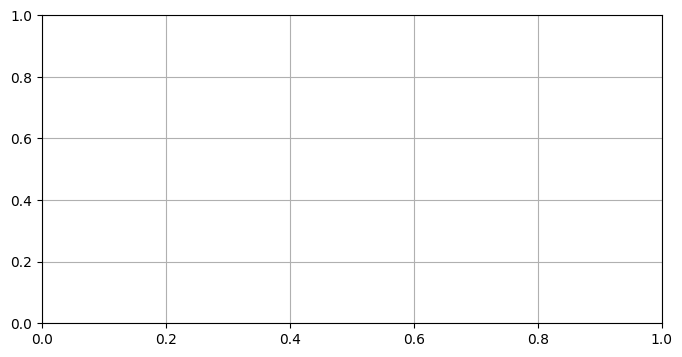

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

NameError: name 'IMAGE_SIZE' is not defined

Confusion Matrix:
[[229  61   3   7]
 [  2 274   9  21]
 [  0   2 297   1]
 [  0   1   0 404]]


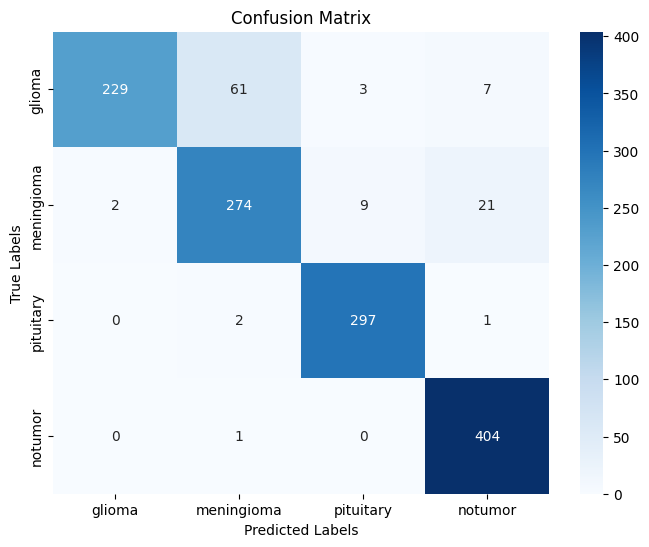

In [ ]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

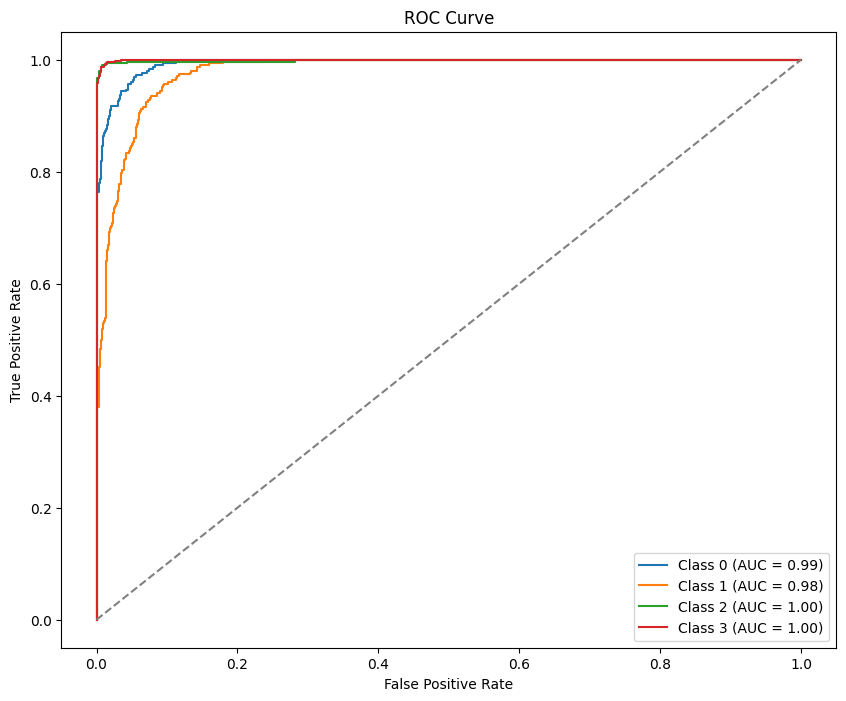

In [ ]:
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save('model.h5')

In [ ]:
from google.colab import files
files.download('/content/model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/model.h5')

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma', 'meningioma', 'pituitary', 'notumor']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step


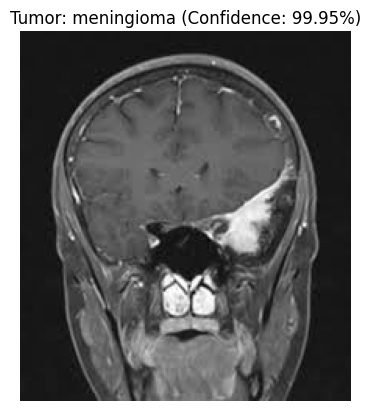

In [ ]:
image_path = '/content/drive/MyDrive/Testing/meningioma/Te-meTr_0003.jpg'

detect_and_display(image_path, model)